In [2]:
#Importamos librerías básicas
import pandas as pd # manipulacion dataframes
import numpy as np  # matrices y vectores
import matplotlib.pyplot as plt #gráfica

In [ ]:
# %pip install scipy pandas


In [ ]:
# %pip install --upgrade --force-reinstall numpy scipy scikit-learn

In [ ]:
# %pip install scikit-learn

In [45]:
from scipy.io import arff

# 1. Load the ARFF file using SciPy
data, meta = arff.loadarff("C:/Users/USUARIO/Documents/Codigos/Proyecto e-commerce/data/data.arff")

# 2. Convert it into a Pandas DataFrame
df = pd.DataFrame(data)

df.head()

,customer_state,total_payment_value,total_freight,total_weight_g,total_volume_cm3,principal_category_by_price,principal_seller_state_by_price,purchase_year,facturacion_promedio_t1,facturacion_mediana_t1,...,dias_entrega_promedio_7d_avg,dias_entrega_promedio_t2,dias_entrega_promedio_prev_month,es_post_domingo_festivo,es_diciembre,es_fin_de_semana_extendido,distancia_km,distancia_total_t1,distancia_total_prev_month,delivery_days
0,b'SP',38.71,8.72,500.0,1976.0,b'utilidades_domesticas',b'SP',2017.0,111.890769,91.660,...,10.860524,10.043478,11.886244,1.0,0.0,0.0,18.576110,4025.883311,291113.407386,8.0
1,b'SP',32.70,12.80,200.0,2560.0,b'cama_mesa_banho',b'SP',2018.0,169.101283,112.680,...,7.619223,9.063401,11.552505,0.0,0.0,0.0,309.131371,25226.900324,488209.852444,4.0
2,b'SP',54.36,16.11,583.0,8400.0,b'brinquedos',b'SP',2018.0,146.652034,100.230,...,14.771980,15.841772,14.586934,0.0,0.0,0.0,430.144201,21694.682189,421109.470293,11.0
3,b'SP',29.75,11.85,250.0,4800.0,b'cama_mesa_banho',b'SP',2017.0,170.919272,117.600,...,12.902686,12.000000,11.846389,0.0,0.0,0.0,209.757656,9623.066166,343516.704227,6.0
4,b'SP',118.86,8.96,525.0,4368.0,b'beleza_saude',b'SP',2017.0,219.488889,106.805,...,11.561738,10.369565,11.021440,1.0,0.0,0.0,11.680956,6110.978959,304388.330097,21.0


In [103]:


# 1. Load the ARFF file using SciPy
# data, meta = arff.loadarff("C:/Users/USUARIO/Documents/Codigos/Proyecto e-commerce/data/data.arff")
data = pd.read_csv("df_final.csv")

# 2. Convert it into a Pandas DataFrame
df = pd.DataFrame(data)

df.head()

,customer_state,total_payment_value,total_freight,total_weight_g,total_volume_cm3,principal_category_by_price,principal_seller_state_by_price,purchase_year,facturacion_promedio_t1,facturacion_mediana_t1,...,dias_entrega_promedio_7d_avg,dias_entrega_promedio_t2,dias_entrega_promedio_prev_month,es_post_domingo_festivo,es_diciembre,es_fin_de_semana_extendido,distancia_km,distancia_total_t1,distancia_total_prev_month,delivery_days
0,SP,38.71,8.72,500.0,1976.0,b'utilidades_domesticas',SP,2017.0,111.890769,91.660,...,10.860524,10.043478,11.886244,1.0,0.0,0.0,18.576110,4025.883311,291113.407386,8.0
1,SP,32.70,12.80,200.0,2560.0,b'cama_mesa_banho',SP,2018.0,169.101283,112.680,...,7.619223,9.063401,11.552505,0.0,0.0,0.0,309.131371,25226.900324,488209.852444,4.0
2,SP,29.75,11.85,250.0,4800.0,b'cama_mesa_banho',SP,2017.0,170.919272,117.600,...,12.902686,12.000000,11.846389,0.0,0.0,0.0,209.757656,9623.066166,343516.704227,6.0
3,SP,118.86,8.96,525.0,4368.0,b'beleza_saude',SP,2017.0,219.488889,106.805,...,11.561738,10.369565,11.021440,1.0,0.0,0.0,11.680956,6110.978959,304388.330097,21.0
4,SP,88.90,8.91,250.0,3960.0,b'beleza_saude',SP,2018.0,138.861099,100.485,...,15.758284,15.924686,14.586934,0.0,0.0,0.0,13.817425,15249.215838,421109.470293,4.0


In [46]:
#Correccion de tipos de datos
df['customer_state']=df['customer_state'].astype('category')
df["principal_category_by_price"] = df["principal_category_by_price"].astype('category')
df["principal_seller_state_by_price"] = df["principal_seller_state_by_price"].astype('category')
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 25516 entries, 0 to 25515
Data columns (total 22 columns):
 #   Column                            Non-Null Count  Dtype   
---  ------                            --------------  -----   
 0   customer_state                    25516 non-null  category
 1   total_payment_value               25516 non-null  float64 
 2   total_freight                     25516 non-null  float64 
 3   total_weight_g                    25516 non-null  float64 
 4   total_volume_cm3                  25516 non-null  float64 
 5   principal_category_by_price       25516 non-null  category
 6   principal_seller_state_by_price   25516 non-null  category
 7   purchase_year                     25516 non-null  float64 
 8   facturacion_promedio_t1           25516 non-null  float64 
 9   facturacion_mediana_t1            25516 non-null  float64 
 10  facturacion_std_t1                25516 non-null  float64 
 11  facturacion_total_7d_avg          25516 non-null  floa

In [121]:
umbral = df["distancia_km"].quantile(0.985)
df = df[df["distancia_km"] <= umbral].reset_index(drop=True)

df = df[df["distancia_km"] > 4].reset_index(drop=True)

<Axes: >

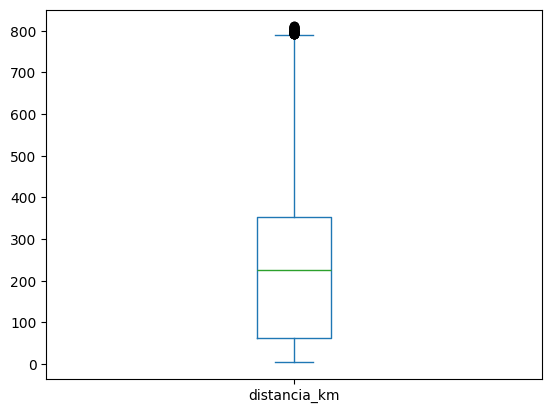

In [122]:
df["distancia_km"].plot(kind='box')


<Axes: >

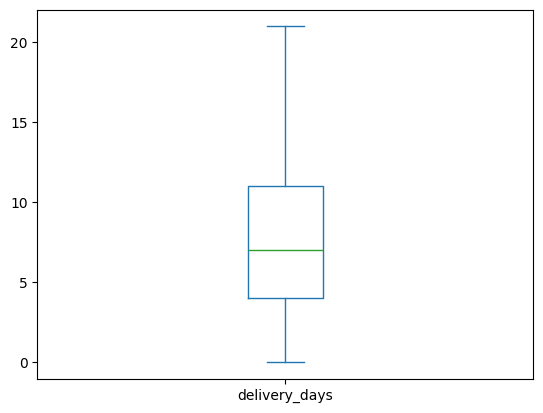

In [16]:
# df = df[df["delivery_days"] > 0].reset_index(drop=True)
df = df[df["delivery_days"] < 22].reset_index(drop=True)


df["delivery_days"].plot(kind='box')


<Axes: >

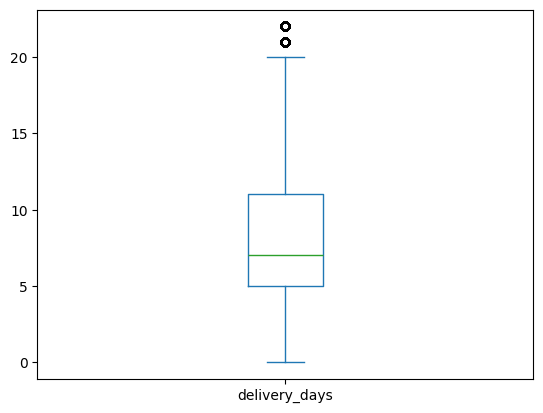

In [269]:
df["delivery_days"].plot(kind='box')


In [210]:
df = df[df["delivery_days"] < 18].reset_index(drop=True)


In [17]:
umbral = df["total_volume_cm3"].quantile(0.95)
df = df[df["total_volume_cm3"] <= umbral].reset_index(drop=True)

print(df.shape)   # esperado: ~24.240 filas (se eliminan ~1.276)

(22327, 22)


<Axes: >

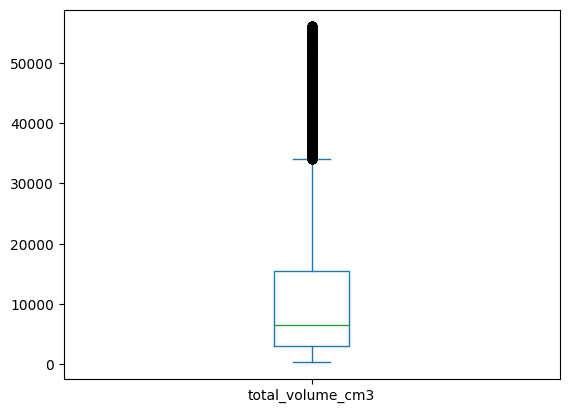

In [237]:
df["total_volume_cm3"].plot(kind='box')



In [18]:
umbral = df["total_weight_g"].quantile(0.95)
df = df[df["total_weight_g"] <= umbral].reset_index(drop=True)

<Axes: >

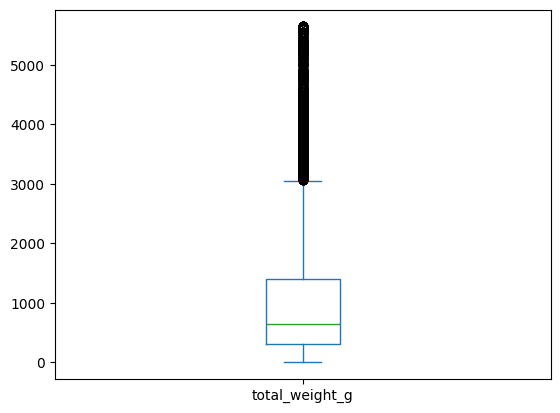

In [58]:
df["total_weight_g"].plot(kind='box')


In [19]:
umbral = df["total_freight"].quantile(0.95)
df = df[df["total_freight"] <= umbral].reset_index(drop=True)
print((df["total_freight"] == 0).sum())   # cuántos registros tienen flete 0

df = df[df["total_freight"] != 0].reset_index(drop=True)
print(df.shape)

122
(20028, 22)


<Axes: >

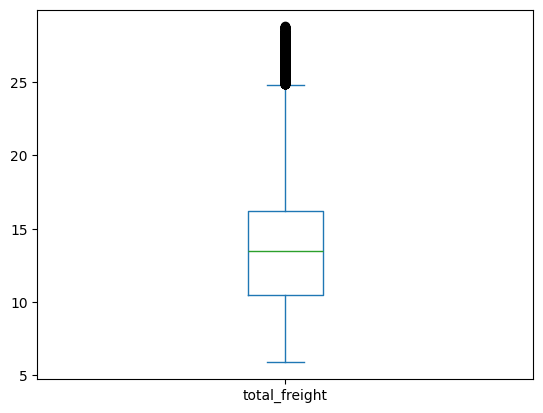

In [20]:
df["total_freight"].plot(kind='box')


0


<Axes: >

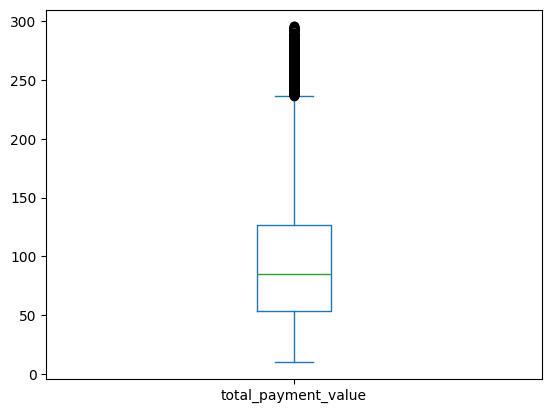

In [21]:
umbral = df["total_payment_value"].quantile(0.95)
df = df[df["total_payment_value"] <= umbral].reset_index(drop=True)
print((df["total_payment_value"] == 0).sum())   # cuántos registros tienen flete 0

df = df[df["total_payment_value"] != 0].reset_index(drop=True)

df["total_payment_value"].plot(kind='box')

<Axes: >

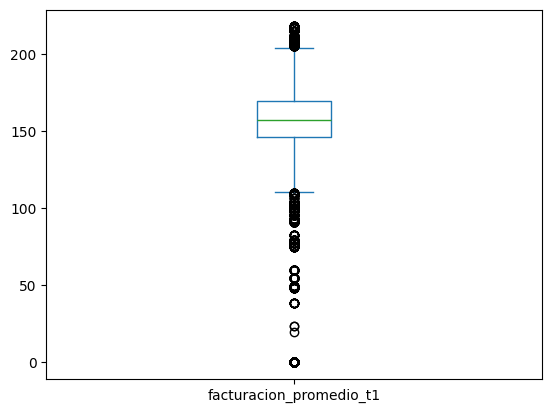

In [22]:
umbral = df["facturacion_promedio_t1"].quantile(0.95)
df = df[df["facturacion_promedio_t1"] <= umbral].reset_index(drop=True)

df["facturacion_promedio_t1"].plot(kind='box')

array([[<Axes: title={'center': 'total_payment_value'}>,
        <Axes: title={'center': 'total_freight'}>,
        <Axes: title={'center': 'total_weight_g'}>,
        <Axes: title={'center': 'total_volume_cm3'}>],
       [<Axes: title={'center': 'purchase_year'}>,
        <Axes: title={'center': 'facturacion_promedio_t1'}>,
        <Axes: title={'center': 'facturacion_mediana_t1'}>,
        <Axes: title={'center': 'facturacion_std_t1'}>],
       [<Axes: title={'center': 'facturacion_total_7d_avg'}>,
        <Axes: title={'center': 'dias_entrega_promedio_7d_avg'}>,
        <Axes: title={'center': 'dias_entrega_promedio_t2'}>,
        <Axes: title={'center': 'dias_entrega_promedio_prev_month'}>],
       [<Axes: title={'center': 'es_post_domingo_festivo'}>,
        <Axes: title={'center': 'es_diciembre'}>,
        <Axes: title={'center': 'es_fin_de_semana_extendido'}>,
        <Axes: title={'center': 'distancia_km'}>],
       [<Axes: title={'center': 'distancia_total_t1'}>,
        <Axes

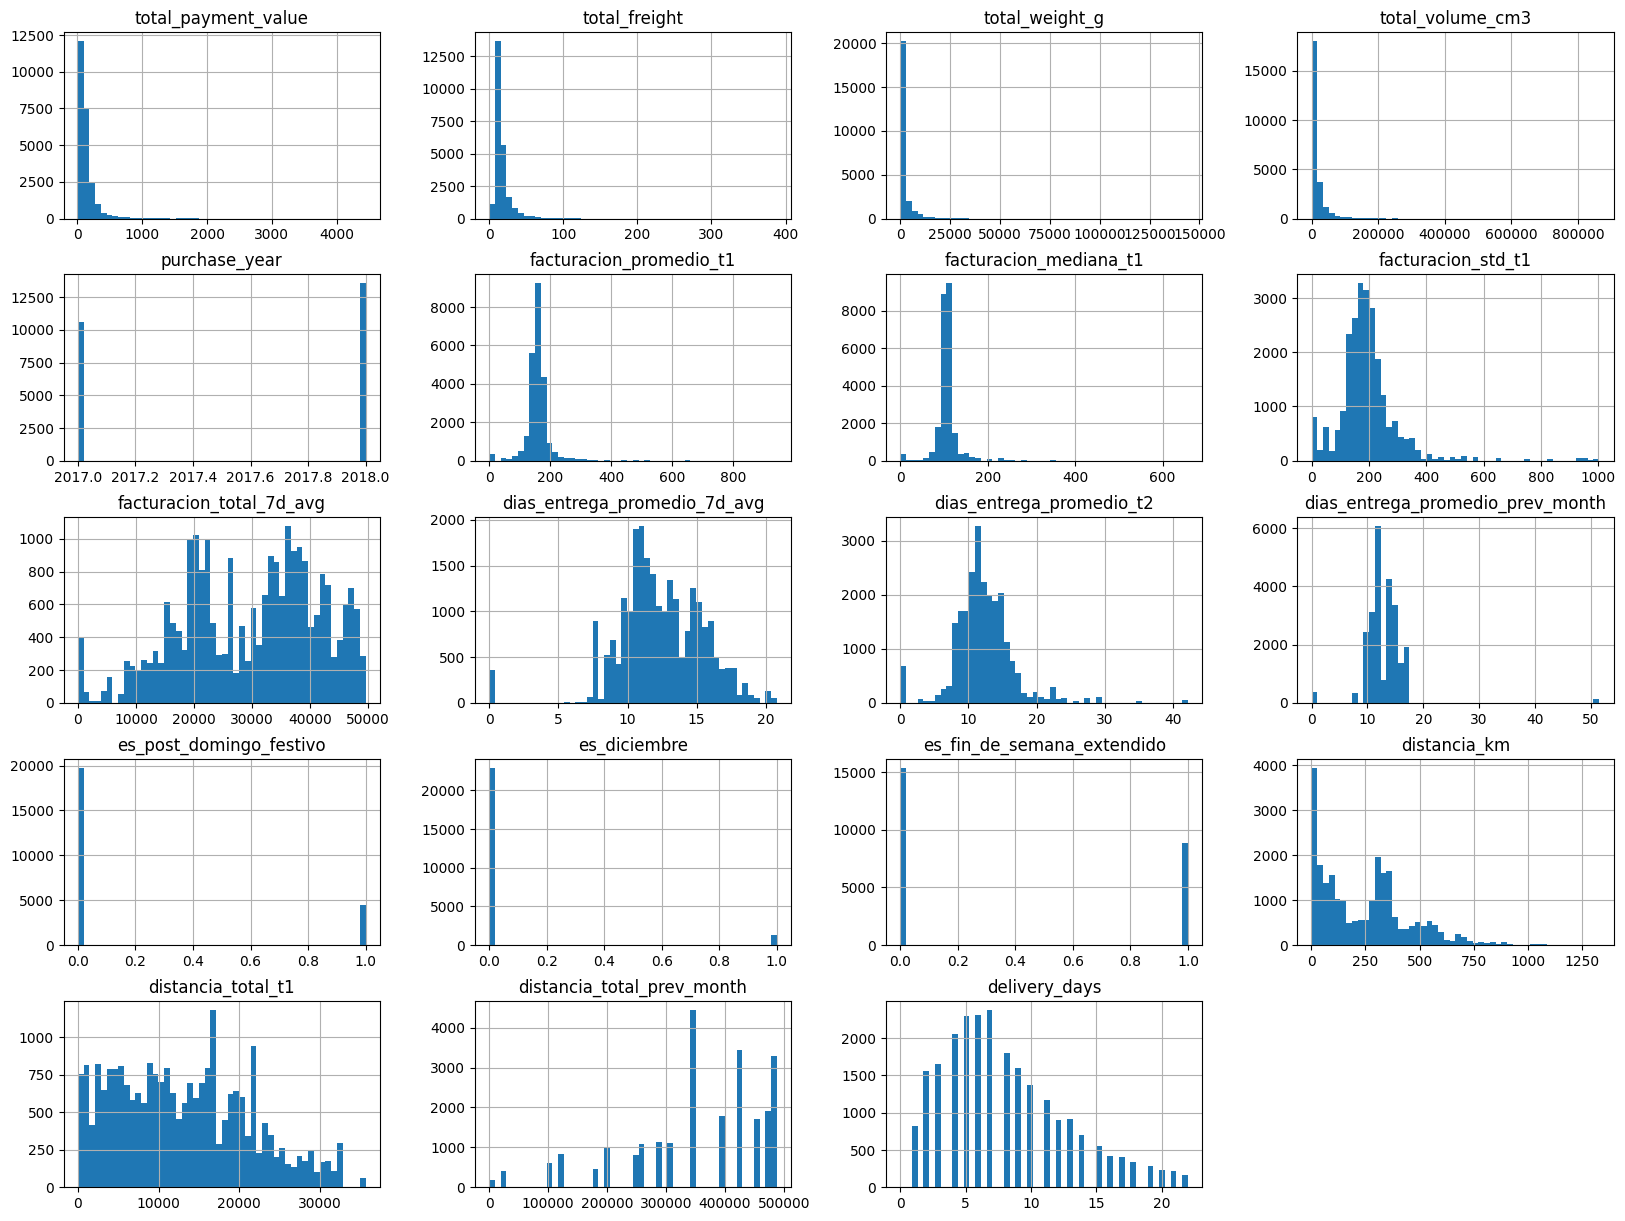

In [104]:
df.hist(bins=50, figsize=(20,15))

In [ ]:
# %pip install ydata-profiling

In [ ]:
# # Perfilado de datos
# from ydata_profiling import ProfileReport

# profile_data=ProfileReport(df, minimal=True) # minimal=False
# profile_data

In [9]:
print(df[cat_cols].isna().sum())
print(df[cat_cols].head())

customer_state                     0
principal_category_by_price        0
principal_seller_state_by_price    0
dtype: int64
  customer_state principal_category_by_price principal_seller_state_by_price
0             SP       utilidades_domesticas                              SP
1             SP             cama_mesa_banho                              SP
2             SP                  brinquedos                              SP
3             SP             cama_mesa_banho                              SP
4             SP                beleza_saude                              SP


In [123]:
df["purchase_year"] = df["purchase_year"].astype(int)
flags = ["es_post_domingo_festivo", "es_diciembre", "es_fin_de_semana_extendido"]
df[flags] = df[flags].astype(int)

cat_cols = ["customer_state", "principal_category_by_price", "principal_seller_state_by_price"]
for col in cat_cols:
    df[col] = (
        df[col].astype(object)
        .map(lambda x: x.decode("utf-8") if isinstance(x, bytes) else x)
        .astype("category")
    )

data = pd.get_dummies(df, columns=cat_cols, drop_first=False, dtype=int)
print(data.shape)
print([c for c in data.columns if "b'" in c])  # debe imprimir []
print(data.head())

(23658, 33)
["principal_category_by_price_b'beleza_saude'", "principal_category_by_price_b'brinquedos'", "principal_category_by_price_b'cama_mesa_banho'", "principal_category_by_price_b'esporte_lazer'", "principal_category_by_price_b'informatica_acessorios'", "principal_category_by_price_b'moveis_decoracao'", "principal_category_by_price_b'relogios_presentes'", "principal_category_by_price_b'utilidades_domesticas'"]
   total_payment_value  total_freight  total_weight_g  total_volume_cm3  \
0                38.71           8.72           500.0            1976.0   
1                32.70          12.80           200.0            2560.0   
2                29.75          11.85           250.0            4800.0   
3               118.86           8.96           525.0            4368.0   
4                88.90           8.91           250.0            3960.0   

   purchase_year  facturacion_promedio_t1  facturacion_mediana_t1  \
0           2017               111.890769                  9

In [124]:
#Se separa variables predictoras y objetivo
objetivo = 'delivery_days'
X = data.drop(objetivo, axis=1)
Y = data[objetivo]
X.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 23658 entries, 0 to 23657
Data columns (total 32 columns):
 #   Column                                                 Non-Null Count  Dtype  
---  ------                                                 --------------  -----  
 0   total_payment_value                                    23658 non-null  float64
 1   total_freight                                          23658 non-null  float64
 2   total_weight_g                                         23658 non-null  float64
 3   total_volume_cm3                                       23658 non-null  float64
 4   purchase_year                                          23658 non-null  int64  
 5   facturacion_promedio_t1                                23658 non-null  float64
 6   facturacion_mediana_t1                                 23658 non-null  float64
 7   facturacion_std_t1                                     23658 non-null  float64
 8   facturacion_total_7d_avg                      

In [125]:
from sklearn.metrics import make_scorer
from sklearn.model_selection import cross_validate
from sklearn import tree

# 1. Creas la función
def wmape_func(y_real, y_pred):
    return np.sum(np.abs(y_real - y_pred)) / np.sum(np.abs(y_real))

# 2. La conviertes en un métrica compatible con Scikit-Learn
# Le ponemos greater_is_better=False para que siga la misma lógica negativa de tus otras métricas
wmape_scorer = make_scorer(wmape_func, greater_is_better=False)

# 3. Lo agregas a tu diccionario de métricas
scoring = {
    'neg_mean_absolute_error': 'neg_mean_absolute_error',
    'neg_mean_squared_error': 'neg_mean_squared_error',
    'neg_root_mean_squared_error': 'neg_root_mean_squared_error',
    'neg_wmape': wmape_scorer, # <--- Tu nueva métrica
    # 'neg_mean_absolute_percentage_error':  'neg_mean_absolute_percentage_error'
}

cv = 10


In [ ]:
#Tree
from sklearn import tree
from sklearn.model_selection import cross_validate

modelTree = tree.DecisionTreeRegressor(criterion='squared_error', min_samples_leaf=1000, max_depth=5, random_state=42)


scores = cross_validate(modelTree, X, Y, cv=cv, scoring=scoring, return_train_score=True, return_estimator=False)
scores=pd.DataFrame(scores) #Se almacenan los resultados en un dataframe
# print(scores)


# 1. Conviertes el diccionario de resultados a un DataFrame
scores_df = pd.DataFrame(scores)

# 2. Ahora sí puedes calcular el promedio
resultados_promedio_dt = scores_df.mean()

# 3. Aplicas el valor absoluto a las métricas de error (a partir de la fila 2)
resultados_promedio_dt[2:] = resultados_promedio_dt[2:].abs()

print(resultados_promedio_dt)



fit_time                              0.071094
score_time                            0.003074
test_neg_mean_absolute_error          3.107203
train_neg_mean_absolute_error         3.094118
test_neg_mean_squared_error          16.115957
train_neg_mean_squared_error         15.979966
test_neg_root_mean_squared_error      4.014082
train_neg_root_mean_squared_error     3.997488
test_neg_wmape                        0.389646
train_neg_wmape                       0.387966
dtype: float64


fit_time                              0.080668
score_time                            0.003375
test_neg_mean_absolute_error          3.080574
train_neg_mean_absolute_error         3.064173
test_neg_mean_squared_error          15.907351
train_neg_mean_squared_error         15.724312
test_neg_root_mean_squared_error      3.987949
train_neg_root_mean_squared_error     3.965378
test_neg_wmape                        0.386311
train_neg_wmape                       0.384212
dtype: float64


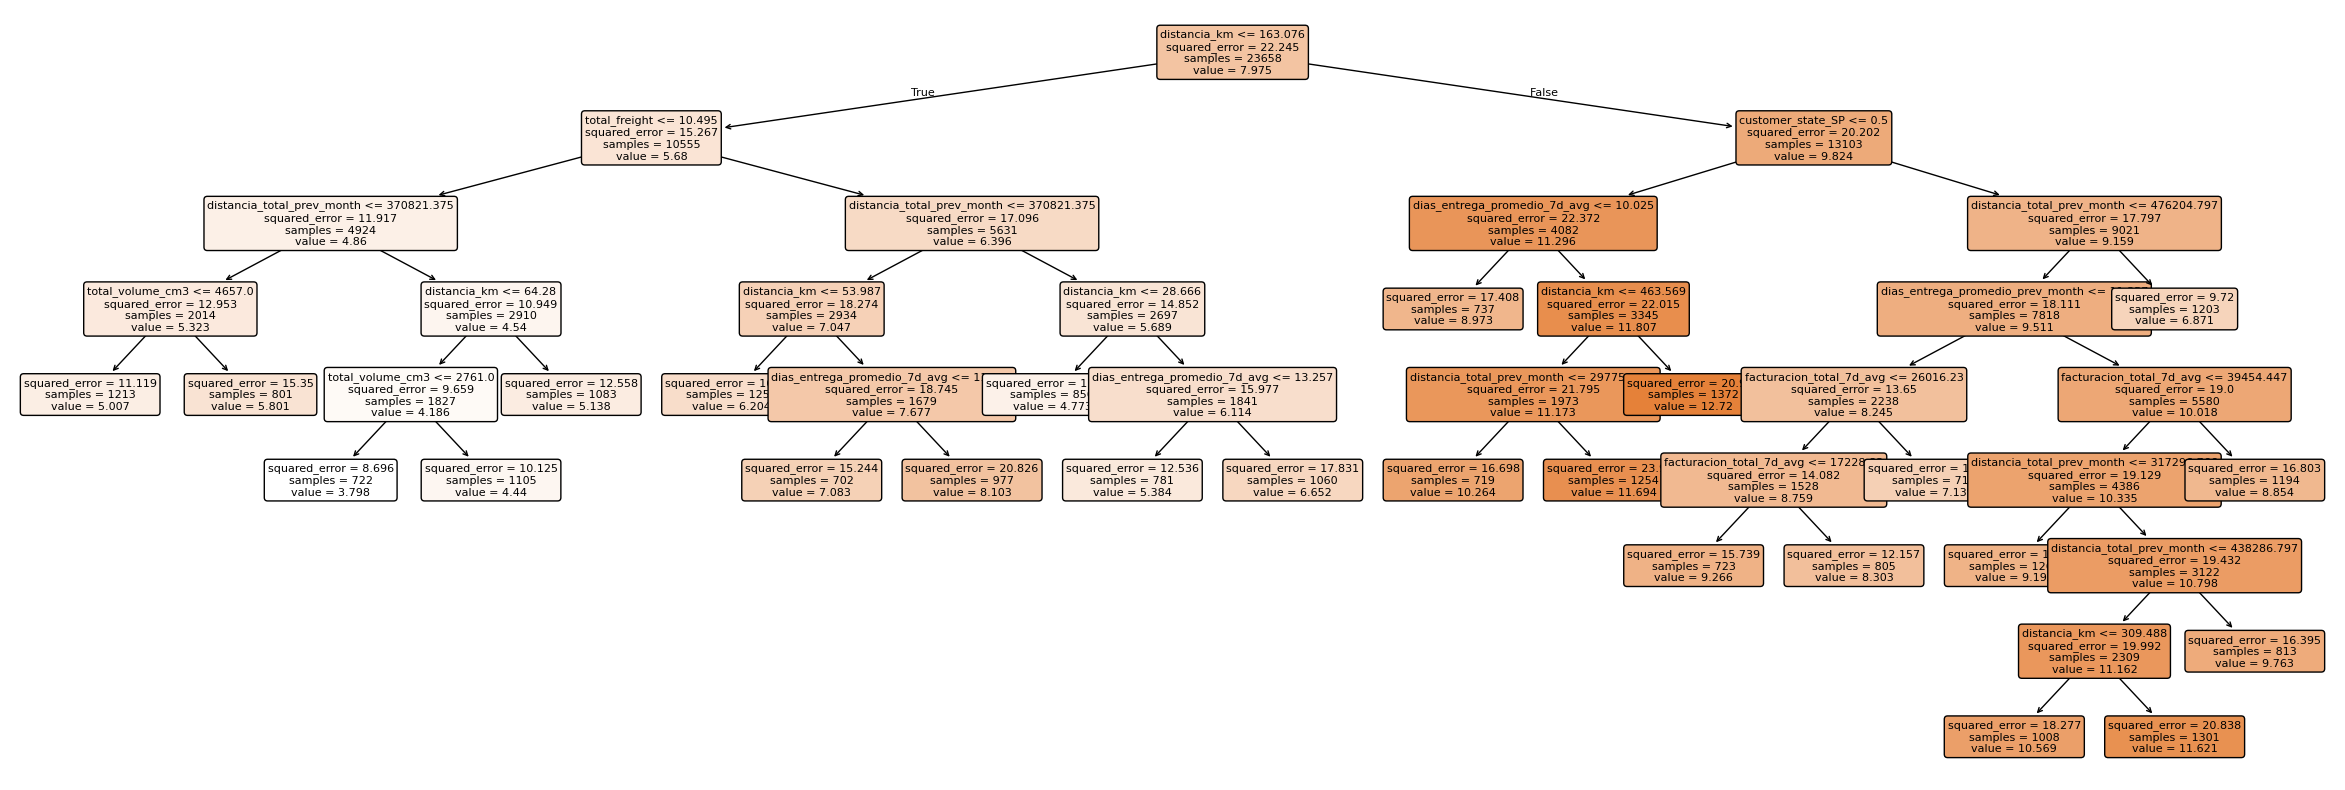

In [244]:
#Tree
from sklearn import tree
from sklearn.model_selection import cross_validate
from sklearn.tree import plot_tree

modelTree = tree.DecisionTreeRegressor(criterion='squared_error', min_samples_leaf=700, max_depth=9, random_state=42)


scores = cross_validate(modelTree, X, Y, cv=cv, scoring=scoring, return_train_score=True, return_estimator=False)
scores=pd.DataFrame(scores) #Se almacenan los resultados en un dataframe
# print(scores)


# 1. Conviertes el diccionario de resultados a un DataFrame
scores_df = pd.DataFrame(scores)

# 2. Ahora sí puedes calcular el promedio
resultados_promedio_dt = scores_df.mean()

# 3. Aplicas el valor absoluto a las métricas de error (a partir de la fila 2)
resultados_promedio_dt[2:] = resultados_promedio_dt[2:].abs()

print(resultados_promedio_dt)

# Entrenamos una instancia para poder visualizarla
modelTree_fit = modelTree.fit(X, Y)

plt.figure(figsize=(30, 10))
plot_tree(modelTree_fit, feature_names=X.columns, filled=True, rounded=True, fontsize=8)
plt.show()

In [ ]:
from sklearn.tree import plot_tree
plt.figure(figsize=(30,30))
plot_tree(modelTree, feature_names=X.columns.values,  rounded=True, filled=True)
plt.show()

In [ ]:
# import pandas as pd

# # 1. Conviertes el diccionario de resultados a un DataFrame
# scores_df = pd.DataFrame(scores)

# # 2. Ahora sí puedes calcular el promedio
# resultados_promedio = scores_df.mean()

# # 3. Aplicas el valor absoluto a las métricas de error (a partir de la fila 2)
# resultados_promedio[2:] = resultados_promedio[2:].abs()

# print(resultados_promedio)

In [268]:
#Random forest
from sklearn import ensemble
modelRf = ensemble.RandomForestRegressor(
    n_estimators=100, max_samples=0.8, criterion='squared_error', min_samples_leaf=100, max_depth=None, max_features=0.8, random_state=42, n_jobs=-1
)
scores = cross_validate(modelRf, X, Y, cv=cv, scoring=scoring, return_train_score=True, return_estimator=False)
scores=pd.DataFrame(scores) #Se almacenan los resultados en un dataframe
# print(scores)

# 1. Conviertes el diccionario de resultados a un DataFrame
scores_df = pd.DataFrame(scores)

# 2. Ahora sí puedes calcular el promedio
resultados_promedio_rf = scores_df.mean()

# 3. Aplicas el valor absoluto a las métricas de error (a partir de la fila 2)
resultados_promedio_rf[2:] = resultados_promedio_rf[2:].abs()

print(resultados_promedio_rf)



fit_time                              0.505874
score_time                            0.031888
test_neg_mean_absolute_error          2.959626
train_neg_mean_absolute_error         2.896067
test_neg_mean_squared_error          14.782606
train_neg_mean_squared_error         14.156426
test_neg_root_mean_squared_error      3.844364
train_neg_root_mean_squared_error     3.762498
test_neg_wmape                        0.371140
train_neg_wmape                       0.363133
dtype: float64


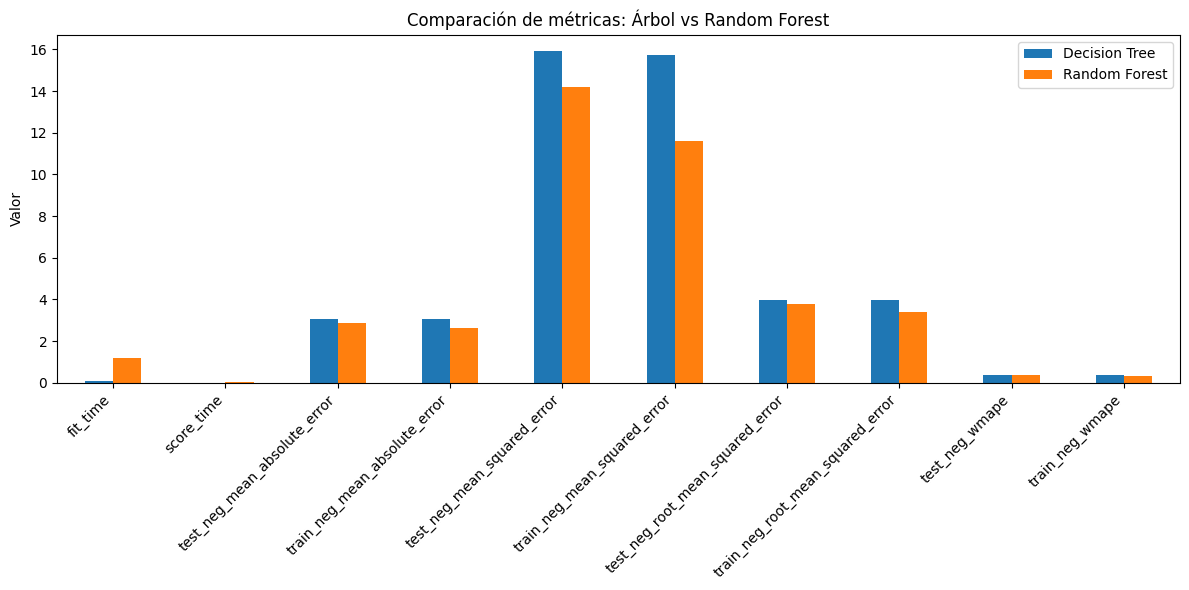

In [207]:
comparacion = pd.DataFrame({'Decision Tree': resultados_promedio_dt, 'Random Forest': resultados_promedio_rf})
comparacion.plot(kind='bar', figsize=(12, 6))
plt.title('Comparación de métricas: Árbol vs Random Forest')
plt.ylabel('Valor')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

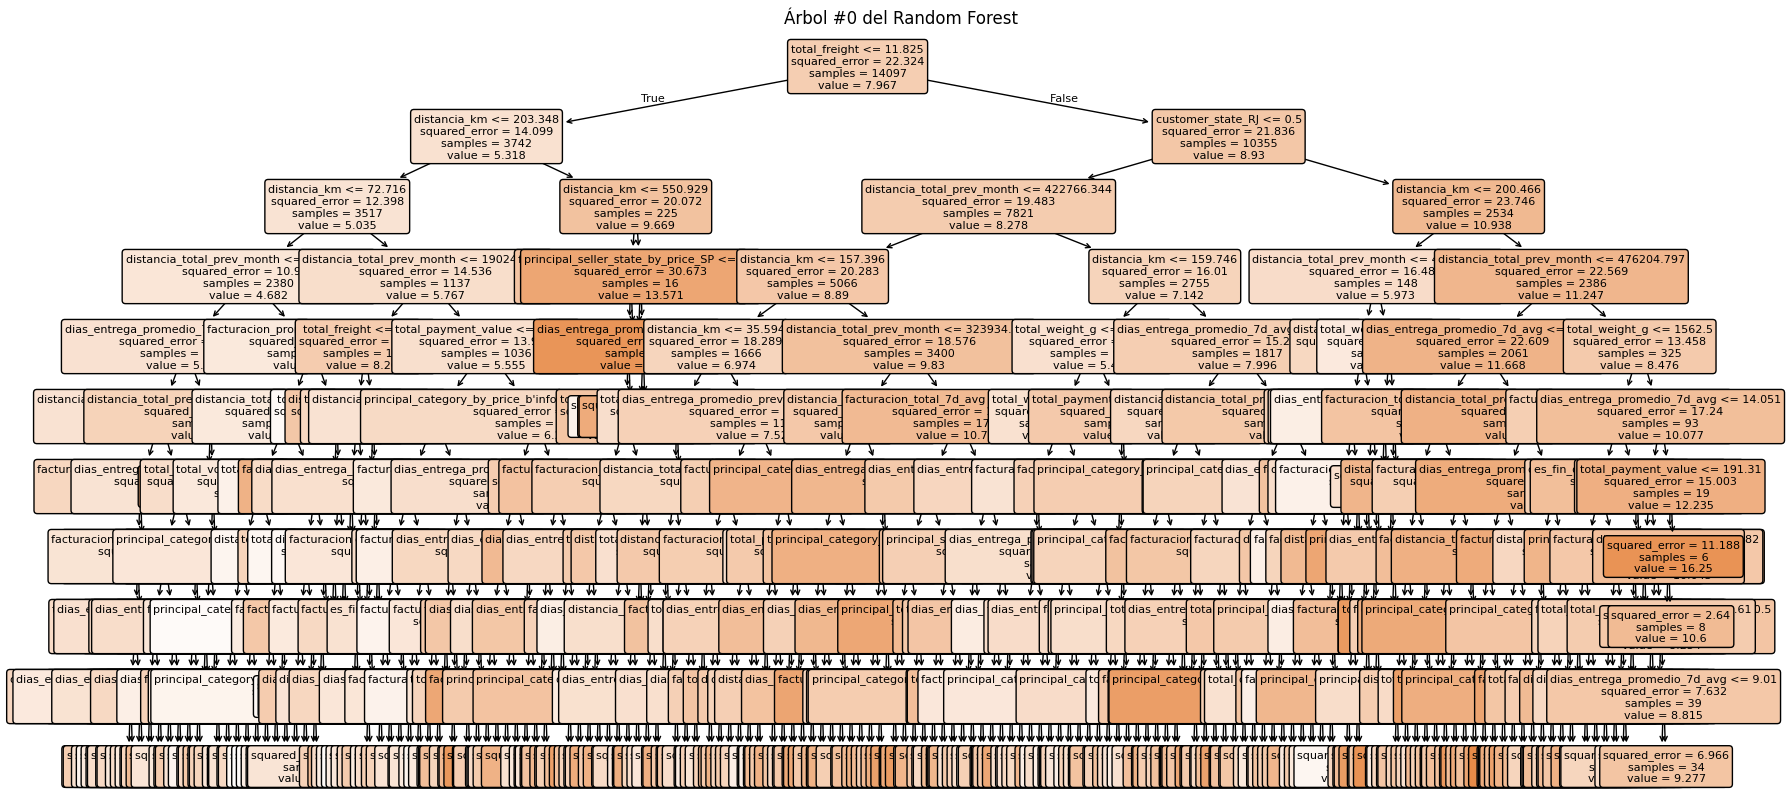

In [208]:
from sklearn.tree import plot_tree

plt.figure(figsize=(20, 10))
plot_tree(modelRf_fit.estimators_[0], feature_names=X.columns, filled=True, rounded=True, fontsize=8)
plt.title('Árbol #0 del Random Forest')
plt.show()

In [ ]:
# 1. Conviertes el diccionario de resultados a un DataFrame
# scores_df = pd.DataFrame(scores)


# # 2. Ahora sí puedes calcular el promedio
# resultados_promedio = scores_df.mean()

# # 3. Aplicas el valor absoluto a las métricas de error (a partir de la fila 2)
# resultados_promedio[2:] = resultados_promedio[2:].abs()

# print(resultados_promedio)

In [209]:
from sklearn.preprocessing import MinMaxScaler

# Solo las variables continuas (dummies y banderas ya están en 0/1)
variables_continuas = [
    'total_payment_value', 'total_freight', 'total_weight_g', 'total_volume_cm3',
    'purchase_year', 'facturacion_promedio_t1', 'facturacion_mediana_t1',
    'facturacion_std_t1', 'facturacion_total_7d_avg',
    'dias_entrega_promedio_7d_avg', 'dias_entrega_promedio_t2',
    'dias_entrega_promedio_prev_month', 'distancia_km',
    'distancia_total_t1', 'distancia_total_prev_month'
]

X_esc = X.copy()
X_esc[variables_continuas] = MinMaxScaler().fit_transform(X[variables_continuas])

X_esc.describe().loc[["min", "max"]]   # verificación: todo entre 0 y 1

,total_payment_value,total_freight,total_weight_g,total_volume_cm3,purchase_year,facturacion_promedio_t1,facturacion_mediana_t1,facturacion_std_t1,facturacion_total_7d_avg,dias_entrega_promedio_7d_avg,...,principal_category_by_price_b'cama_mesa_banho',principal_category_by_price_b'esporte_lazer',principal_category_by_price_b'informatica_acessorios',principal_category_by_price_b'moveis_decoracao',principal_category_by_price_b'relogios_presentes',principal_category_by_price_b'utilidades_domesticas',principal_seller_state_by_price_MG,principal_seller_state_by_price_PR,principal_seller_state_by_price_RJ,principal_seller_state_by_price_SP
min,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
max,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,...,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0


In [153]:
X_esc.describe()   # verificación: todo entre 0 y 1

,total_payment_value,total_freight,total_weight_g,total_volume_cm3,purchase_year,facturacion_promedio_t1,facturacion_mediana_t1,facturacion_std_t1,facturacion_total_7d_avg,dias_entrega_promedio_7d_avg,...,principal_category_by_price_cama_mesa_banho,principal_category_by_price_esporte_lazer,principal_category_by_price_informatica_acessorios,principal_category_by_price_moveis_decoracao,principal_category_by_price_relogios_presentes,principal_category_by_price_utilidades_domesticas,principal_seller_state_by_price_MG,principal_seller_state_by_price_PR,principal_seller_state_by_price_RJ,principal_seller_state_by_price_SP
count,19052.000000,19052.000000,19052.000000,19052.000000,19052.00000,19052.000000,19052.000000,19052.000000,19052.000000,19052.000000,...,19052.000000,19052.000000,19052.000000,19052.000000,19052.000000,19052.000000,19052.000000,19052.000000,19052.000000,19052.000000
mean,0.305780,0.342449,0.175341,0.166165,0.56477,0.709441,0.528733,0.321562,0.603482,0.593371,...,0.200189,0.142347,0.109175,0.109017,0.096525,0.103821,0.058367,0.072696,0.050126,0.818812
std,0.199790,0.194487,0.179425,0.175219,0.49580,0.139552,0.104720,0.132764,0.236615,0.148603,...,0.400152,0.349415,0.311867,0.311669,0.295318,0.305036,0.234441,0.259643,0.218211,0.385184
min,0.000000,0.000000,0.000000,0.000000,0.00000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,0.153330,0.219344,0.051681,0.044390,0.00000,0.673360,0.501974,0.248800,0.417757,0.508151,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000
50%,0.260755,0.325777,0.106195,0.096346,1.00000,0.725204,0.533025,0.318203,0.648722,0.575515,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000
75%,0.406190,0.441710,0.238938,0.236867,1.00000,0.782946,0.566302,0.384169,0.790141,0.702399,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000
max,1.000000,1.000000,1.000000,1.000000,1.00000,1.000000,1.000000,1.000000,1.000000,1.000000,...,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000


In [216]:
#KNN
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import MinMaxScaler  # o StandardScaler
from sklearn.neighbors import KNeighborsRegressor

model_knn = KNeighborsRegressor(n_neighbors=500, metric='euclidean', n_jobs=-1)
scores = cross_validate(model_knn, X_esc, Y, cv=cv, scoring=scoring, return_train_score=True, return_estimator=False)
scores=pd.DataFrame(scores) #Se almacenan los resultados en un dataframe

# print(scores)

scores_knn = pd.DataFrame(scores)


# 2. Ahora sí puedes calcular el promedio
resultados_promedio_knn = scores_knn.mean()

# 3. Aplicas el valor absoluto a las métricas de error (a partir de la fila 2)
resultados_promedio_knn[2:] = resultados_promedio_knn[2:].abs()

print(resultados_promedio_knn)

fit_time                              0.007849
score_time                            0.289059
test_neg_mean_absolute_error          3.308019
train_neg_mean_absolute_error         3.300634
test_neg_mean_squared_error          17.793718
train_neg_mean_squared_error         17.716747
test_neg_root_mean_squared_error      4.217701
train_neg_root_mean_squared_error     4.209121
test_neg_wmape                        0.414834
train_neg_wmape                       0.413861
dtype: float64


In [297]:
#Red neuronal
from sklearn.neural_network import MLPRegressor

model_rn = MLPRegressor(activation="relu", hidden_layer_sizes=(35), learning_rate_init=0.001, momentum= 0.02, max_iter=1500, random_state=42, verbose=False)

scores = cross_validate(model_rn, X_esc, Y, cv=cv, scoring=scoring,
                        return_train_score=True, return_estimator=False)
scores_rn = pd.DataFrame(scores)
# print(scores_rn)

resultados_promedio_rn = scores_rn.mean()
resultados_promedio_rn[2:] = resultados_promedio_rn[2:].abs()
print(resultados_promedio_rn)

#2 

fit_time                             11.287971
score_time                            0.003311
test_neg_mean_absolute_error          3.025128
train_neg_mean_absolute_error         2.952245
test_neg_mean_squared_error          15.489344
train_neg_mean_squared_error         14.762297
test_neg_root_mean_squared_error      3.935299
train_neg_root_mean_squared_error     3.842146
test_neg_wmape                        0.379332
train_neg_wmape                       0.370177
dtype: float64


In [ ]:
X_esc.head()

In [ ]:
model_rn.fit(X_esc, Y)
plt.figure(figsize=(8, 4))
plt.plot(model_rn.loss_curve_)
plt.xlabel("Época")
plt.ylabel("Pérdida (error cuadrático / 2)")
plt.title("Curva de pérdida de la red neuronal")
plt.grid(True)
plt.show()

In [ ]:
# #SVM
# from sklearn.svm import SVR

# model_svm = SVR(kernel='rbf', C=10)

# scores = cross_validate(model_svm, X_esc, Y, cv=cv, scoring=scoring,
#                         return_train_score=True, return_estimator=False)
# scores_svm = pd.DataFrame(scores)

# resultados_promedio_svm = scores_svm.mean()
# resultados_promedio_svm[2:] = resultados_promedio_svm[2:].abs()
# print(resultados_promedio_svm)

In [259]:
#AdaBoost
from sklearn.ensemble import AdaBoostRegressor
from sklearn.tree import DecisionTreeRegressor

model_ada = AdaBoostRegressor(
    estimator=DecisionTreeRegressor(max_depth=9, min_samples_leaf=3),
    n_estimators=200, learning_rate=0.1, loss='linear', random_state=42
)

scores = cross_validate(model_ada, X, Y, cv=cv, scoring=scoring,
                        return_train_score=True, return_estimator=False)
scores_ada = pd.DataFrame(scores)

resultados_promedio_ada = scores_ada.mean()
resultados_promedio_ada[2:] = resultados_promedio_ada[2:].abs()
print(resultados_promedio_ada)

fit_time                             18.834772
score_time                            0.072617
test_neg_mean_absolute_error          3.109912
train_neg_mean_absolute_error         2.788117
test_neg_mean_squared_error          14.877701
train_neg_mean_squared_error         11.164463
test_neg_root_mean_squared_error      3.856756
train_neg_root_mean_squared_error     3.341310
test_neg_wmape                        0.392718
train_neg_wmape                       0.351988
dtype: float64


In [ ]:
# %pip install xgboost

In [312]:
#XGBoost
from xgboost import XGBRegressor

model_xgb = XGBRegressor(
    n_estimators=500, learning_rate=0.05, max_depth=3, subsample=0.7, colsample_bytree=0.9, random_state=42, n_jobs=-1
)

scores = cross_validate(model_xgb, X, Y, cv=cv, scoring=scoring,
                        return_train_score=True, return_estimator=False)
scores_xgb = pd.DataFrame(scores)

resultados_promedio_xgb = scores_xgb.mean()
resultados_promedio_xgb[2:] = resultados_promedio_xgb[2:].abs()
print(resultados_promedio_xgb)

fit_time                              0.441270
score_time                            0.008457
test_neg_mean_absolute_error          2.879677
train_neg_mean_absolute_error         2.767285
test_neg_mean_squared_error          14.162821
train_neg_mean_squared_error         13.042753
test_neg_root_mean_squared_error      3.762893
train_neg_root_mean_squared_error     3.611470
test_neg_wmape                        0.361109
train_neg_wmape                       0.346985
dtype: float64


In [ ]:
from sklearn.ensemble import VotingRegressor
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import MinMaxScaler
from sklearn.tree import DecisionTreeRegressor
from sklearn.neighbors import KNeighborsRegressor
from sklearn.neural_network import MLPRegressor
from xgboost import XGBRegressor

model_dt = DecisionTreeRegressor(criterion='squared_error', min_samples_leaf=9, random_state=42)

model_knn = make_pipeline(
    MinMaxScaler(),
    KNeighborsRegressor(n_neighbors=15, metric='euclidean', n_jobs=-1)
)

model_rn = make_pipeline(
    MinMaxScaler(),
    MLPRegressor(activation="relu", hidden_layer_sizes=(40),
                 learning_rate_init=0.01, max_iter=1800, random_state=42)
)

model_xgb = XGBRegressor(
    n_estimators=100, learning_rate=0.05, max_depth=4,
    subsample=0.8, colsample_bytree=0.8,
    random_state=42, n_jobs=-1
)

regresores = [('dt', model_dt), ('knn', model_knn), ('net', model_rn), ('f', model_xgb)] #('net', model_rn)

model_vot_simple = VotingRegressor(estimators=regresores)                       # "hard"
model_vot_pond   = VotingRegressor(estimators=regresores, weights=[0.1, 0.2, 0.3, 0.4])  # "soft"

resultados_vot = {}
for nombre, m in [("Votacion_simple", model_vot_simple), ("Votacion_ponderada", model_vot_pond)]:
    s = pd.DataFrame(cross_validate(m, X, Y, cv=cv, scoring=scoring, return_train_score=True))
    r = s.mean()
    cols = [c for c in r.index if c.startswith(("test_", "train_"))]
    r[cols] = r[cols].abs()
    resultados_vot[nombre] = r

print(pd.DataFrame(resultados_vot).T)

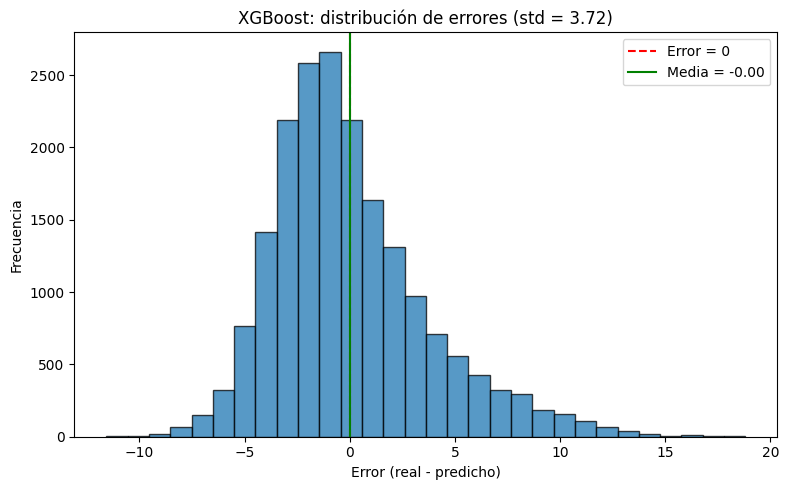

In [250]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.base import clone
from sklearn.model_selection import check_cv

X_arr = np.asarray(X)
y_arr = np.ravel(Y)
cv_obj = check_cv(cv, y_arr, classifier=False)   # funciona aunque cv sea un entero

errores = []
for idx_train, idx_test in cv_obj.split(X_arr, y_arr):
    modelo = clone(model_xgb).fit(X_arr[idx_train], y_arr[idx_train])
    pred = modelo.predict(X_arr[idx_test])
    errores.extend(y_arr[idx_test] - pred)       # error = real - predicho

errores = np.array(errores)

plt.figure(figsize=(8, 5))
plt.hist(errores, bins=30, edgecolor="black", alpha=0.75)
plt.axvline(0, color="red", linestyle="--", label="Error = 0")
plt.axvline(errores.mean(), color="green", label=f"Media = {errores.mean():.2f}")
plt.title(f"XGBoost: distribución de errores (std = {errores.std():.2f})")
plt.xlabel("Error (real - predicho)")
plt.ylabel("Frecuencia")
plt.legend()
plt.tight_layout()
plt.show()

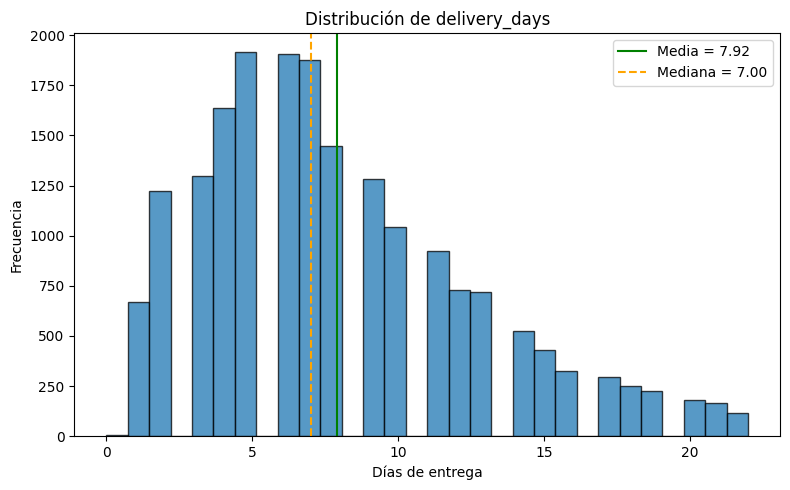

In [252]:
import matplotlib.pyplot as plt

col = "delivery_days"   # cambia por el nombre exacto de tu columna
datos = df[col].dropna()

plt.figure(figsize=(8, 5))
plt.hist(datos, bins=30, edgecolor="black", alpha=0.75)
plt.axvline(datos.mean(), color="green", label=f"Media = {datos.mean():.2f}")
plt.axvline(datos.median(), color="orange", linestyle="--", label=f"Mediana = {datos.median():.2f}")
plt.title(f"Distribución de {col}")
plt.xlabel("Días de entrega")
plt.ylabel("Frecuencia")
plt.legend()
plt.tight_layout()
plt.show()

=== % de pedidos que llegan a más tardar en (predicho + margen) ===
Margen  0.00 días ->  58.29%
Margen  1.00 días ->  68.29%
Margen  2.00 días ->  75.86%
Margen  3.00 días ->  81.99%
Margen  3.72 días ->  85.30%
Margen  5.00 días ->  89.74%
Margen  7.00 días ->  94.32%
Margen 10.00 días ->  98.18%

=== Margen necesario para una cobertura objetivo ===
80% de los pedidos llegan a más tardar en predicho + 2.63 días (redondeado: +3)
90% de los pedidos llegan a más tardar en predicho + 5.08 días (redondeado: +6)
95% de los pedidos llegan a más tardar en predicho + 7.43 días (redondeado: +8)
99% de los pedidos llegan a más tardar en predicho + 11.26 días (redondeado: +12)


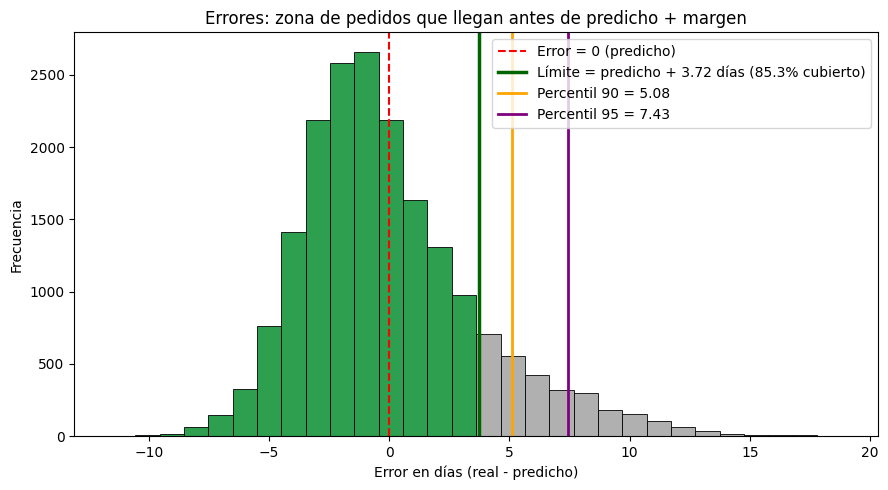

In [261]:
import numpy as np
import matplotlib.pyplot as plt

sigma = errores.std()

# 1) Cobertura con márgenes fijos: % de pedidos que llegan a más tardar en predicho + margen
print("=== % de pedidos que llegan a más tardar en (predicho + margen) ===")
for m in [0, 1, 2, 3, sigma, 5, 7, 10]:
    print(f"Margen {m:5.2f} días -> {np.mean(errores <= m) * 100:6.2f}%")

# 2) Margen necesario para alcanzar una cobertura objetivo
print("\n=== Margen necesario para una cobertura objetivo ===")
for p in [80, 90, 95, 99]:
    m = np.percentile(errores, p)
    print(f"{p}% de los pedidos llegan a más tardar en predicho + {m:.2f} días "
          f"(redondeado: +{int(np.ceil(m))})")
# 3) Gráfico: histograma de errores resaltando la zona cubierta
p90 = np.percentile(errores, 90)
p95 = np.percentile(errores, 95)
limite = sigma          # cambia a p90 o p95 para resaltar otra cobertura
cobertura = np.mean(errores <= limite) * 100

fig, ax = plt.subplots(figsize=(9, 5))

# Histograma calculado a mano para poder colorear cada barra
conteos, bordes = np.histogram(errores, bins=30)
centros = (bordes[:-1] + bordes[1:]) / 2
anchos = np.diff(bordes)
colores = np.where(bordes[1:] <= limite, "#2e9e4f", "#b0b0b0")   # verde = cubierto, gris = fuera

ax.bar(centros, conteos, width=anchos, color=colores, edgecolor="black", linewidth=0.6)

# Líneas de referencia
ax.axvline(0, color="red", linestyle="--", linewidth=1.5, label="Error = 0 (predicho)")
ax.axvline(limite, color="darkgreen", linewidth=2.5,
           label=f"Límite = predicho + {limite:.2f} días ({cobertura:.1f}% cubierto)")
ax.axvline(p90, color="orange", linewidth=2, label=f"Percentil 90 = {p90:.2f}")
ax.axvline(p95, color="purple", linewidth=2, label=f"Percentil 95 = {p95:.2f}")

ax.set_title("Errores: zona de pedidos que llegan antes de predicho + margen")
ax.set_xlabel("Error en días (real - predicho)")
ax.set_ylabel("Frecuencia")
ax.legend()
plt.tight_layout()
plt.show()

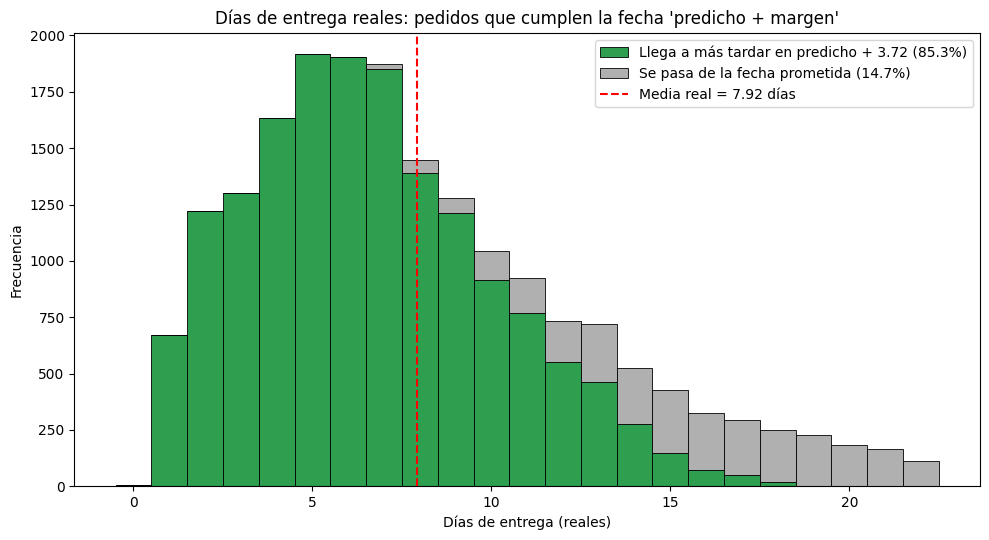

Cobertura por rango de días de entrega reales:
    0.0 a   4.0 días -> 100.0% cubierto
    4.0 a   7.0 días ->  99.7% cubierto
    7.0 a  11.0 días ->  93.4% cubierto
   11.0 a  22.0 días ->  48.0% cubierto


In [264]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import cross_val_predict

# 1) Predicciones out-of-fold alineadas con cada fila de Y
y_real = np.ravel(Y)
y_pred = np.ravel(cross_val_predict(model_xgb, X, Y, cv=cv))
err = y_real - y_pred

# 2) Margen elegido (cambia a p90 o p95 si quieres otra cobertura)
p90 = np.percentile(err, 90)
p95 = np.percentile(err, 95)
margen = err.std()            # o p90 / p95

fecha_prometida = y_pred + margen
cubierto = y_real <= fecha_prometida
cobertura = cubierto.mean() * 100

# 3) Histograma de días de entrega REALES, apilado por cubierto / no cubierto
bins = np.arange(np.floor(y_real.min()) - 0.5, np.ceil(y_real.max()) + 1.5, 1)

fig, ax = plt.subplots(figsize=(10, 5.5))
ax.hist([y_real[cubierto], y_real[~cubierto]], bins=bins, stacked=True,
        color=["#2e9e4f", "#b0b0b0"], edgecolor="black", linewidth=0.6,
        label=[f"Llega a más tardar en predicho + {margen:.2f} ({cobertura:.1f}%)",
               f"Se pasa de la fecha prometida ({100 - cobertura:.1f}%)"])

ax.axvline(y_real.mean(), color="red", linestyle="--", linewidth=1.5,
           label=f"Media real = {y_real.mean():.2f} días")
ax.set_title("Días de entrega reales: pedidos que cumplen la fecha 'predicho + margen'")
ax.set_xlabel("Días de entrega (reales)")
ax.set_ylabel("Frecuencia")
ax.legend()
plt.tight_layout()
plt.show()

# 4) Cobertura por rango de días reales
print("Cobertura por rango de días de entrega reales:")
cortes = np.percentile(y_real, [0, 25, 50, 75, 100])
for i in range(4):
    m = (y_real >= cortes[i]) & (y_real <= cortes[i + 1])
    print(f"  {cortes[i]:5.1f} a {cortes[i+1]:5.1f} días -> {cubierto[m].mean()*100:5.1f}% cubierto")

In [263]:
print(np.sort(np.unique(y_real))[:30])   # valores distintos de días
print(np.mean(y_real == np.round(y_real)))   # fracción de valores enteros (1.0 = todos)

[ 0.  1.  2.  3.  4.  5.  6.  7.  8.  9. 10. 11. 12. 13. 14. 15. 16. 17.
 18. 19. 20. 21. 22.]
1.0


In [251]:
import numpy as np

sigma = errores.std()   # 3.58 en tu caso

# 1) Literal: real <= predicho + std  (error <= std)
pct_debajo = np.mean(errores <= sigma) * 100

# 2) Dentro de la banda: predicho - std <= real <= predicho + std  (|error| <= std)
pct_banda = np.mean(np.abs(errores) <= sigma) * 100

# Extra: la misma banda con 2 desviaciones
pct_banda_2 = np.mean(np.abs(errores) <= 2 * sigma) * 100

print(f"Desviación estándar del error: {sigma:.2f}")
print(f"Real <= predicho + 1 std        : {pct_debajo:.2f}%")
print(f"Real dentro de predicho ± 1 std : {pct_banda:.2f}%")
print(f"Real dentro de predicho ± 2 std : {pct_banda_2:.2f}%")

Desviación estándar del error: 3.72
Real <= predicho + 1 std        : 85.30%
Real dentro de predicho ± 1 std : 73.07%
Real dentro de predicho ± 2 std : 94.53%


In [ ]:
   from sklearn.pipeline import make_pipeline
   from sklearn.preprocessing import MinMaxScaler

   model_dt  = DecisionTreeRegressor(min_samples_leaf=9, random_state=42)
   model_knn = make_pipeline(MinMaxScaler(), KNeighborsRegressor(n_neighbors=5, n_jobs=-1))
   model_rn  = make_pipeline(MinMaxScaler(), MLPRegressor(hidden_layer_sizes=(40,10), learning_rate_init=0.01, max_iter=700, random_state=42))

                                   Decision Tree  Random Forest    XGBoost  \
fit_time                                0.080668       0.505874   0.441270   
score_time                              0.003375       0.031888   0.008457   
test_neg_mean_absolute_error            3.080574       2.959626   2.879677   
train_neg_mean_absolute_error           3.064173       2.896067   2.767285   
test_neg_mean_squared_error            15.907351      14.782606  14.162821   
train_neg_mean_squared_error           15.724312      14.156426  13.042753   
test_neg_root_mean_squared_error        3.987949       3.844364   3.762893   
train_neg_root_mean_squared_error       3.965378       3.762498   3.611470   
test_neg_wmape                          0.386311       0.371140   0.361109   
train_neg_wmape                         0.384212       0.363133   0.346985   

                                   Red Neuronal  
fit_time                              11.287971  
score_time                             0.

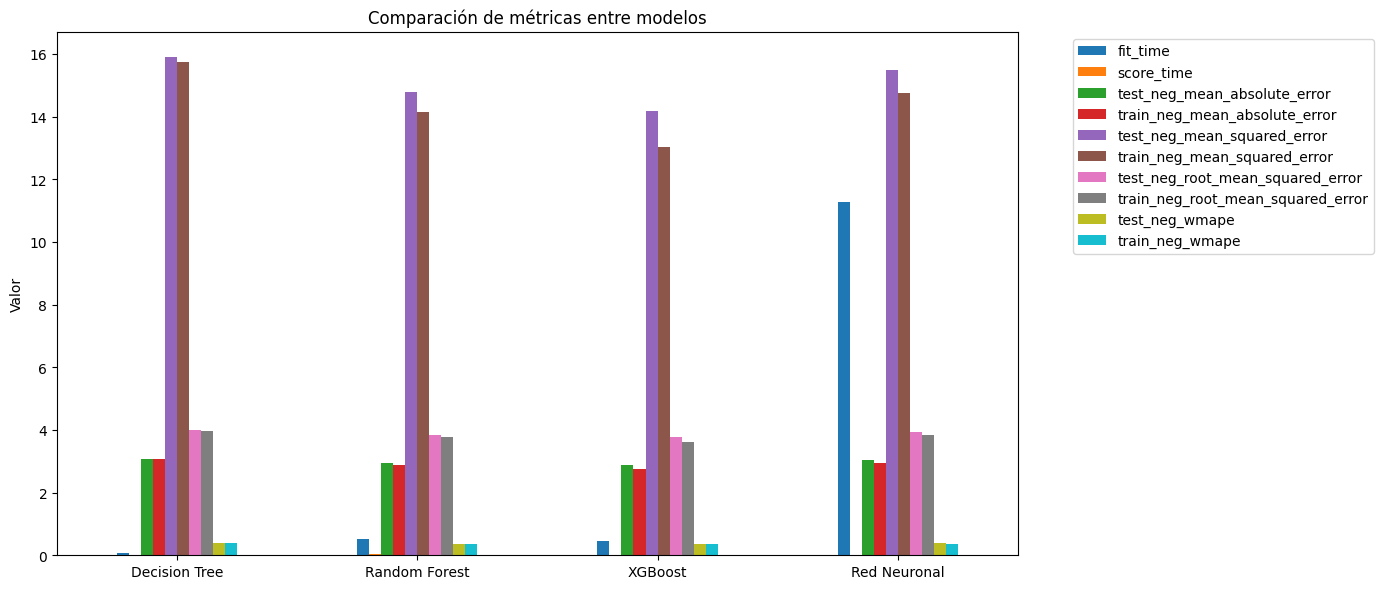

In [313]:
comparacion = pd.DataFrame({
    'Decision Tree': resultados_promedio_dt,
    'Random Forest': resultados_promedio_rf,
    'XGBoost': resultados_promedio_xgb,
    'Red Neuronal': resultados_promedio_rn
})

print(comparacion)

comparacion.T.plot(kind='bar', figsize=(14, 6))
plt.title('Comparación de métricas entre modelos')
plt.ylabel('Valor')
plt.xticks(rotation=0)
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

In [314]:
import time
import joblib
import os
import numpy as np

# Entrenamiento final de cada modelo (con todos los datos)
modelTree_final = tree.DecisionTreeRegressor(criterion='squared_error', min_samples_leaf=700, max_depth=9, random_state=42).fit(X, Y)

modelRf_final = ensemble.RandomForestRegressor(
    n_estimators=200, max_samples=0.9, criterion='squared_error',
    min_samples_leaf=5, max_depth=10, max_features=0.7, random_state=42, n_jobs=-1
).fit(X, Y)

modelXgb_final = XGBRegressor(
    n_estimators=500, learning_rate=0.05, max_depth=3, subsample=0.7,
    colsample_bytree=0.9, random_state=42, n_jobs=-1
).fit(X, Y)

modelRn_final = MLPRegressor(
    activation="relu", hidden_layer_sizes=(40), learning_rate_init=0.001,
    momentum=0.02, max_iter=1800, random_state=42, verbose=False
).fit(X_esc, Y)

In [315]:
modelos = {
    'Decision Tree': modelTree_final,
    'Random Forest': modelRf_final,
    'XGBoost': modelXgb_final,
    'Red Neuronal': modelRn_final
}

tamaños = {}
for nombre, modelo in modelos.items():
    archivo = f'{nombre.replace(" ", "_")}.pkl'
    joblib.dump(modelo, archivo)
    tamaños[nombre] = os.path.getsize(archivo) / 1024  # en KB

for nombre, kb in tamaños.items():
    print(f"{nombre}: {kb:.2f} KB")

Decision Tree: 5.64 KB
Random Forest: 13036.53 KB
XGBoost: 582.11 KB
Red Neuronal: 58.95 KB


In [316]:
def medir_latencia(modelo, X_sample, n=100, escalado=False):
    datos = X_esc.iloc[[0]] if escalado else X.iloc[[0]]
    tiempos = []
    for _ in range(n):
        inicio = time.time()
        modelo.predict(datos)
        tiempos.append(time.time() - inicio)
    return np.mean(tiempos) * 1000  # ms

print(f"Decision Tree: {medir_latencia(modelTree_final, X):.3f} ms")
print(f"Random Forest: {medir_latencia(modelRf_final, X):.3f} ms")
print(f"XGBoost: {medir_latencia(modelXgb_final, X):.3f} ms")
print(f"Red Neuronal: {medir_latencia(modelRn_final, X_esc, escalado=True):.3f} ms")

Decision Tree: 0.832 ms
Random Forest: 42.947 ms
XGBoost: 2.933 ms
Red Neuronal: 0.885 ms


In [317]:
resumen = pd.DataFrame({
    'Tamaño (KB)': tamaños,
    'Latencia (ms)': {
        'Decision Tree': medir_latencia(modelTree_final, X),
        'Random Forest': medir_latencia(modelRf_final, X),
        'XGBoost': medir_latencia(modelXgb_final, X),
        'Red Neuronal': medir_latencia(modelRn_final, X_esc, escalado=True)
    }
})
resumen = resumen.join(comparacion.T[['test_r2']] if 'test_r2' in comparacion.T.columns else comparacion.T)
print(resumen)

                Tamaño (KB)  Latencia (ms)   fit_time  score_time  \
Decision Tree      5.641602       0.676877   0.080668    0.003375   
Random Forest  13036.532227      39.486458   0.505874    0.031888   
XGBoost          582.112305       2.574773   0.441270    0.008457   
Red Neuronal      58.952148       0.774586  11.287971    0.003311   

               test_neg_mean_absolute_error  train_neg_mean_absolute_error  \
Decision Tree                      3.080574                       3.064173   
Random Forest                      2.959626                       2.896067   
XGBoost                            2.879677                       2.767285   
Red Neuronal                       3.025128                       2.952245   

               test_neg_mean_squared_error  train_neg_mean_squared_error  \
Decision Tree                    15.907351                     15.724312   
Random Forest                    14.782606                     14.156426   
XGBoost                          14